In [100]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

In [101]:
sr = 16000
y, sr = librosa.load("sample_data/sample.wav", sr=sr)

#.wav 파일의 샘플링 주파수와 오디오 신호의 길이를 출력합니다.
print (sr)
print (y.shape)
print (len(y)/sr)

16000
(224000,)
14.0


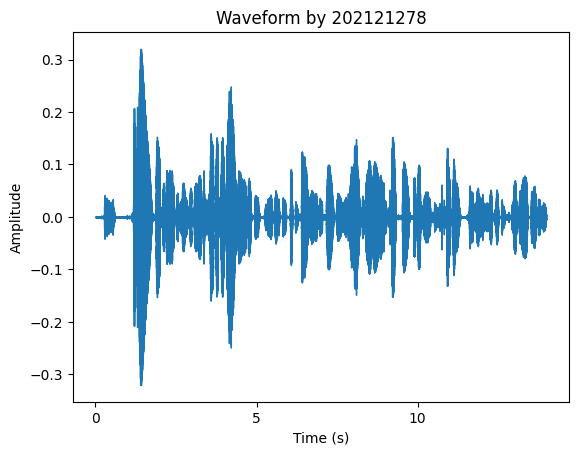

In [102]:
#Waveform
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform by 202121278")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [103]:
#Spectrogram
#Frame settings
frame_length_ms = 25
frame_shift_ms = 10

win_length = int(sr * frame_length_ms / 1000)
hop_length = int(sr * frame_shift_ms / 1000)
n_fft = 400

# Short-Time Fourier Transform
X = librosa.stft(
    y,
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=win_length
)

In [104]:
X[:2,:2]

array([[ 0.00024849+0.j        , -0.00259107+0.j        ],
       [-0.00102268-0.00052152j,  0.00195318+0.00019787j]],
      dtype=complex64)

In [105]:
# Power Spectrogram
S = np.abs(X) ** 2

# Log Power Spectrogram
log_S = np.log(S + 1e-10)

print(np.min(S), np.max(S), S.shape)
print(np.min(log_S), np.max(log_S), log_S.shape)

7.660677e-15 139.61407 (201, 1401)
-23.025774 4.938882 (201, 1401)


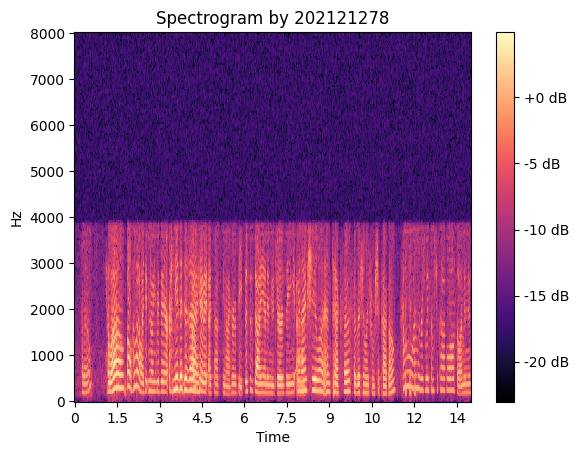

(201, 1401)


In [106]:
# Plot Spectrogram
librosa.display.specshow(
    log_S,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram by 202121278")
plt.show()
print(log_S.shape)

In [107]:
#Mel Spectrogram
# Mel filter settings
n_mels = 40

mel_filter = librosa.filters.mel(
    sr=sr,
    n_fft=n_fft,
    n_mels=n_mels,
    #norm=None
)

mel_filter.shape
mel_filter[0]

array([-0.        ,  0.00739021,  0.01240452,  0.00501431,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

In [108]:
# Mel Spectrogram
mel_spec = mel_filter @ S
print(mel_filter.shape, S.shape, mel_spec.shape)


(40, 201) (201, 1401) (40, 1401)


In [109]:
# Log-Mel Spectrogram
log_mel = np.log(mel_spec + 1e-10)
print(mel_spec.min(), mel_spec.max())
print(log_mel.min(), log_mel.max())

1.7304311e-10 2.16751
-22.02139 0.77357906


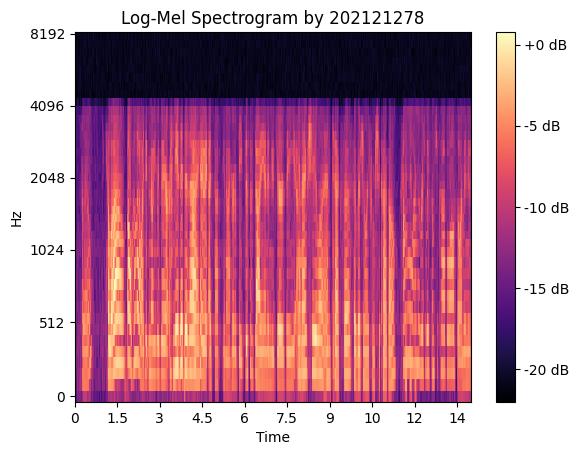

In [110]:
# Plot Log-Mel Spectrogram
librosa.display.specshow(
    log_mel,
    sr=sr,
    hop_length=hop_length,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram by 202121278")
plt.show()

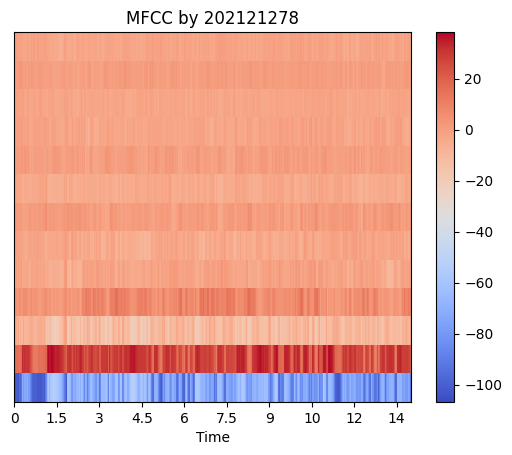

(40, 1401) (13, 1401)


In [111]:
# MFCC
mfcc = librosa.feature.mfcc(
    S=log_mel,
    n_mfcc=13
)

# Plot MFCC
librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr,
    hop_length=hop_length,
    cmap="coolwarm"
)

plt.colorbar()
plt.title("MFCC by 202121278")
plt.show()

print(mel_spec.shape, mfcc.shape)